# Phase 1 - Contrôle Qualité des Données (application_train)

Ce notebook réalise une analyse complète de la qualité des données du dataset principal.

Objectifs :
- Comprendre la structure des données
- Identifier les valeurs manquantes
- Détecter les doublons
- Vérifier les règles métier
- Détecter les valeurs aberrantes (outliers)
- Analyser la variable cible

## 1. Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import zscore

pd.set_option("display.max_columns", 200)

## 2. Chargement des données

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw"

train = pd.read_csv(DATA_PATH / "application_train.csv")

print("Shape :", train.shape)
train.head()

Shape : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 3. Aperçu global

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [4]:
resume = pd.DataFrame({
    "colonne": train.columns,
    "type": train.dtypes.astype(str),
    "valeurs_manquantes": train.isna().sum(),
    "pourcentage_manquant": train.isna().mean() * 100,
    "n_unique": train.nunique()
})

resume.sort_values(by="pourcentage_manquant", ascending=False).head(20)

,colonne,type,valeurs_manquantes,pourcentage_manquant,n_unique
COMMONAREA_AVG,COMMONAREA_AVG,float64,214865,69.872297,3181
COMMONAREA_MODE,COMMONAREA_MODE,float64,214865,69.872297,3128
COMMONAREA_MEDI,COMMONAREA_MEDI,float64,214865,69.872297,3202
NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.432963,214
NONLIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,float64,213514,69.432963,167
NONLIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,float64,213514,69.432963,386
FONDKAPREMONT_MODE,FONDKAPREMONT_MODE,str,210295,68.386172,4
LIVINGAPARTMENTS_AVG,LIVINGAPARTMENTS_AVG,float64,210199,68.354953,1868
LIVINGAPARTMENTS_MEDI,LIVINGAPARTMENTS_MEDI,float64,210199,68.354953,1097
LIVINGAPARTMENTS_MODE,LIVINGAPARTMENTS_MODE,float64,210199,68.354953,736


## 4. Analyse des valeurs manquantes

In [5]:
missing = train.isna().mean().sort_values(ascending=False) * 100
missing.head(20)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

Observation : certaines variables présentent un taux élevé de valeurs manquantes (>50%). Une stratégie de traitement sera nécessaire (suppression ou imputation).

## 5. Vérification des doublons

In [6]:
train.duplicated().sum()

np.int64(0)

Observation : vérifier également l’unicité de l’identifiant client.

In [7]:
train["SK_ID_CURR"].duplicated().sum()

np.int64(0)

## 6. Analyse de la variable cible

In [8]:
train["TARGET"].value_counts()
train["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Observation : la variable cible est déséquilibrée, ce qui aura un impact sur le modèle.

## 7. Vérification des règles métier

In [9]:
{
    "revenu_negatif": (train["AMT_INCOME_TOTAL"] < 0).sum(),
    "enfants_negatif": (train["CNT_CHILDREN"] < 0).sum(),
    "credit_negatif": (train["AMT_CREDIT"] < 0).sum()
}

{'revenu_negatif': np.int64(0),
 'enfants_negatif': np.int64(0),
 'credit_negatif': np.int64(0)}

Observation : aucune valeur négative attendue pour ces variables.

## 8. Détection des outliers (toutes les variables numériques)

In [10]:
num_cols = train.select_dtypes(include=["int64","float64"]).columns

outliers = {}

for col in num_cols:
    data = train[col].fillna(0)
    z = zscore(data)
    outliers[col] = (abs(z) > 3).sum()

outliers_df = pd.DataFrame.from_dict(outliers, orient="index", columns=["nb_outliers"])
outliers_df.sort_values(by="nb_outliers", ascending=False).head(20)

,nb_outliers
FLAG_DOCUMENT_6,27078
FLAG_DOCUMENT_8,25024
TARGET,24825
REG_CITY_NOT_LIVE_CITY,24039
FLAG_EMAIL,17442
REG_REGION_NOT_WORK_REGION,15612
LIVE_REGION_NOT_WORK_REGION,12503
AMT_REQ_CREDIT_BUREAU_WEEK,8536
REGION_POPULATION_RELATIVE,8412
ELEVATORS_AVG,7572


Observation : plusieurs variables présentent des valeurs extrêmes, notamment les variables financières.

## 9. Analyse de distribution

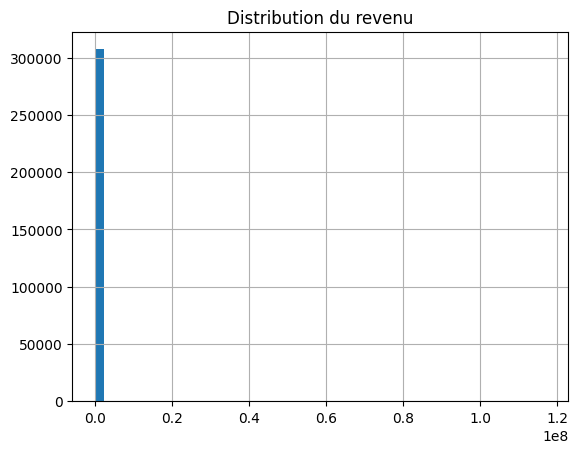

In [11]:
plt.figure()
train["AMT_INCOME_TOTAL"].hist(bins=50)
plt.title("Distribution du revenu")
plt.show()

## 10. Conclusion

Principales conclusions :

- Présence importante de valeurs manquantes
- Dataset globalement propre (peu de doublons)
- Variable cible déséquilibrée
- Présence d’outliers significatifs
- Nécessité de mettre en place un contrôle qualité automatisé (Pandera / Great Expectations)

Prochaine étape :
- Formaliser ces règles dans un pipeline de validation automatique